In [ ]:
%pip install --index-url https://download.pytorch.org/whl/cu128 torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA

sys.path.append('..')

from src.data_processing import load_dataset
from src.model import build_ae_encoder, build_ae_decoder, build_vae_encoder, build_vae_decoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch Version:', torch.__version__)
print('Using device:', device)
if torch.cuda.is_available():
    print('CUDA device:', torch.cuda.get_device_name(0))

BATCH_SIZE = 64
LATENT_DIM = 32
EPOCHS = 10
DATA_DIR = '../data/raw/Medical MNIST'

train_dataset, class_names = load_dataset(DATA_DIR, BATCH_SIZE)
print('Found classes:', class_names)

sample_images, sample_labels = next(iter(train_dataset))
print('Sample batch shape:', tuple(sample_images.shape))

PyTorch Version: 2.11.0+cu128
Using device: cuda
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
Found classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Sample batch shape: (64, 1, 64, 64)


In [2]:
ae_encoder = build_ae_encoder(latent_dim=LATENT_DIM).to(device)
ae_decoder = build_ae_decoder(latent_dim=LATENT_DIM).to(device)
vae_encoder = build_vae_encoder(latent_dim=LATENT_DIM).to(device)
vae_decoder = build_vae_decoder(latent_dim=LATENT_DIM).to(device)

ae_optimizer = torch.optim.Adam(list(ae_encoder.parameters()) + list(ae_decoder.parameters()), lr=1e-3)
vae_optimizer = torch.optim.Adam(list(vae_encoder.parameters()) + list(vae_decoder.parameters()), lr=1e-3)

def train_step_ae(images):
    ae_optimizer.zero_grad()
    latent = ae_encoder(images)
    reconstructed = ae_decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstructed, images)
    loss.backward()
    ae_optimizer.step()
    return loss.item()

def train_step_vae(images):
    vae_optimizer.zero_grad()
    z_mean, z_log_var, z = vae_encoder(images)
    reconstructed = vae_decoder(z)

    recon_loss = torch.nn.functional.binary_cross_entropy(reconstructed, images, reduction='mean')
    recon_loss = recon_loss * (64 * 64)
    kl_loss = -0.5 * torch.mean(1 + z_log_var - torch.square(z_mean) - torch.exp(z_log_var))
    total_loss = recon_loss + kl_loss

    total_loss.backward()
    vae_optimizer.step()
    return recon_loss.item(), kl_loss.item()

In [3]:
ae_loss_history = []
vae_recon_loss_history = []
vae_kl_loss_history = []

print(f'Starting Training for {EPOCHS} Epochs...')
for epoch in range(EPOCHS):
    ae_epoch_losses = []
    vae_epoch_recons = []
    vae_epoch_kls = []

    for images, _ in train_dataset:
        images = images.to(device)
        ae_loss = train_step_ae(images)
        ae_epoch_losses.append(ae_loss)

        recon_loss, kl_loss = train_step_vae(images)
        vae_epoch_recons.append(recon_loss)
        vae_epoch_kls.append(kl_loss)

    ae_epoch_loss = float(np.mean(ae_epoch_losses))
    vae_epoch_recon = float(np.mean(vae_epoch_recons))
    vae_epoch_kl = float(np.mean(vae_epoch_kls))

    ae_loss_history.append(ae_epoch_loss)
    vae_recon_loss_history.append(vae_epoch_recon)
    vae_kl_loss_history.append(vae_epoch_kl)

    print(f'Epoch {epoch + 1}/{EPOCHS} | AE Loss: {ae_epoch_loss:.4f} | VAE Recon: {vae_epoch_recon:.4f} | VAE KL: {vae_epoch_kl:.4f}')

Starting Training for 10 Epochs...
Epoch 1/10 | AE Loss: 0.0151 | VAE Recon: 2005.2120 | VAE KL: 3.6421
Epoch 2/10 | AE Loss: 0.0079 | VAE Recon: 1920.5539 | VAE KL: 3.4640
Epoch 3/10 | AE Loss: 0.0068 | VAE Recon: 1906.4182 | VAE KL: 3.4452
Epoch 4/10 | AE Loss: 0.0062 | VAE Recon: 1898.8614 | VAE KL: 3.4360
Epoch 5/10 | AE Loss: 0.0059 | VAE Recon: 1894.7914 | VAE KL: 3.4242
Epoch 6/10 | AE Loss: 0.0056 | VAE Recon: 1890.7717 | VAE KL: 3.4201
Epoch 7/10 | AE Loss: 0.0054 | VAE Recon: 1888.8676 | VAE KL: 3.4172
Epoch 8/10 | AE Loss: 0.0052 | VAE Recon: 1887.0964 | VAE KL: 3.4107
Epoch 9/10 | AE Loss: 0.0051 | VAE Recon: 1885.0494 | VAE KL: 3.4143
Epoch 10/10 | AE Loss: 0.0050 | VAE Recon: 1882.8700 | VAE KL: 3.4197


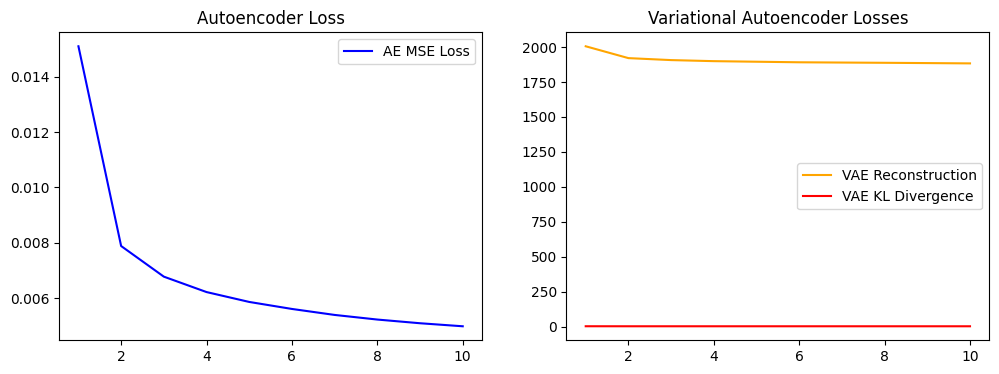

In [4]:
epochs_range = range(1, len(ae_loss_history) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, ae_loss_history, label='AE MSE Loss', color='blue')
plt.title('Autoencoder Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_range, vae_recon_loss_history, label='VAE Reconstruction', color='orange')
plt.plot(epochs_range, vae_kl_loss_history, label='VAE KL Divergence', color='red')
plt.title('Variational Autoencoder Losses')
plt.legend()
plt.show()

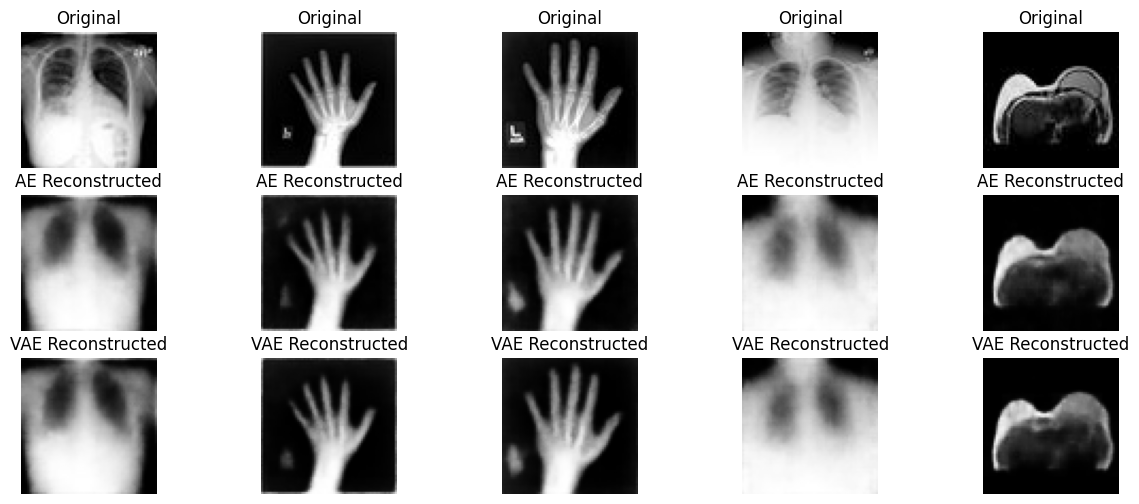

In [5]:
with torch.no_grad():
    input_images = sample_images[:5].to(device)
    ae_recon = ae_decoder(ae_encoder(input_images)).cpu().numpy()
    _, _, vae_z = vae_encoder(input_images)
    vae_recon = vae_decoder(vae_z).cpu().numpy()

orig_images = sample_images[:5].cpu().numpy()

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(3, 5, i + 1); plt.imshow(orig_images[i].squeeze(), cmap='gray'); plt.title('Original'); plt.axis('off')
    plt.subplot(3, 5, i + 6); plt.imshow(ae_recon[i].squeeze(), cmap='gray'); plt.title('AE Reconstructed'); plt.axis('off')
    plt.subplot(3, 5, i + 11); plt.imshow(vae_recon[i].squeeze(), cmap='gray'); plt.title('VAE Reconstructed'); plt.axis('off')
plt.show()

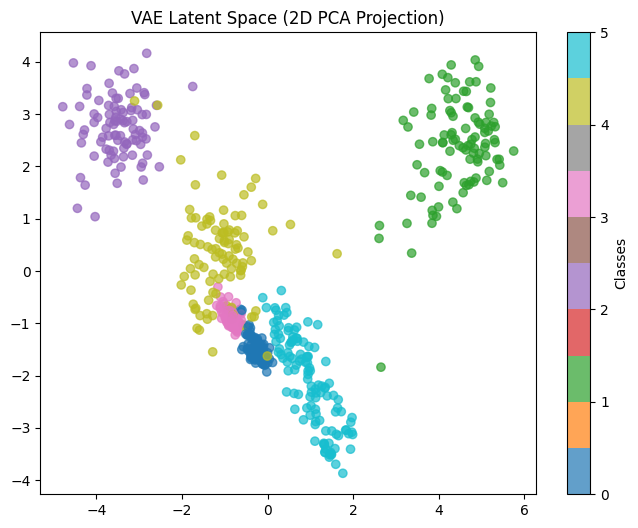

In [6]:
all_z = []
all_labels = []
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(train_dataset):
        if batch_idx >= 10:
            break
        _, _, z = vae_encoder(images.to(device))
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_z = np.vstack(all_z)
all_labels = np.concatenate(all_labels)

pca = PCA(n_components=2)
z_2d = pca.fit_transform(all_z)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(len(class_names)), label='Classes')
plt.title('VAE Latent Space (2D PCA Projection)')
plt.show()

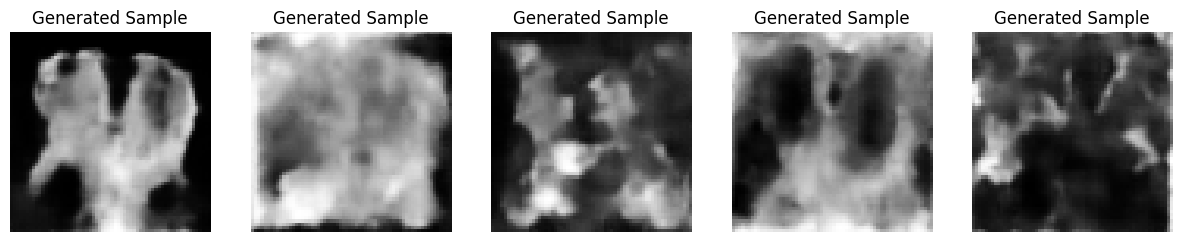

In [11]:
with torch.no_grad():
    random_latent_vectors = torch.randn(5, LATENT_DIM, device=device)
    generated_images = vae_decoder(random_latent_vectors).cpu().numpy()

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1); plt.imshow(generated_images[i].squeeze(), cmap='gray'); plt.title('Generated Sample'); plt.axis('off')
plt.show()